In [ ]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Google Cloud Agentic Data Cloud: Data Profile & Data Quality Pipeline

This notebook serves as the initial step in establishing end-to-end metadata governance for the `thelook_ecommerce` dataset using the Google Cloud **Dataplex DataScan API**. It automates the generation, execution, and monitoring of **Data Profile** scans (column distribution and statistical profiling) and **Data Quality** scans (rule-based schema validation).

---

## 1. Overview & Architecture

This demo combines BigQuery, Knowledge Catalog, Property Graphs, and Conversational Analytics to cleanse enterprise raw data and establish a robust metadata governance pipeline that maximizes the precision of natural language conversational agents.

### Core Technologies Covered
- **Data Warehouse & Modeling**: BigQuery, BigQuery Property Graph
- **Metadata Governance**: Knowledge Catalog (Business Glossary setup), DataScans (automated profiling, quality validation, column/dataset descriptions)
- **BigQuery In-Engine AI/ML**: BigQuery ML (text embedding generation and cosine vector search), High-Level AI Functions (CLASSIFY, SIMILARITY, IF, SEARCH)
- **Conversational Analytics Validation**: Text-to-SQL/GQL agent validation with physical-mapping ruleset testing

---

## 2. Lab Dataset Information (`thelook_ecommerce`)

This lab uses a cloned copy of the public `thelook_ecommerce` dataset, representing synthetic operations of an eCommerce platform.

### 2.1. Table Specifications & Data Structure

| Table Name | Role | Description |
| :--- | :--- | :--- |
| `users` | Customer Info | Demographic, geographic, and acquisition channel data for registered users |
| `products` | Product Catalog | Unique product IDs, categories, brands, and retail prices |
| `orders` | Order Records | Order lifecycle status (shipped, complete, returned) and creation timestamps |
| `order_items` | Order Line Items | Individual items per order, actual sale prices, and fulfillment status |
| `events` | Web Activity Logs | User clickstream sessions (cart additions, product views, purchases) |
| `inventory_items` | Inventory Stock | Cost of goods, warehouse storage location, and dispatch tracking |
| `distribution_centers` | Logistics Hubs | Distribution center names and geographic latitude/longitude coordinates |

### 2.2. Entity Relationship Diagram (ERD)

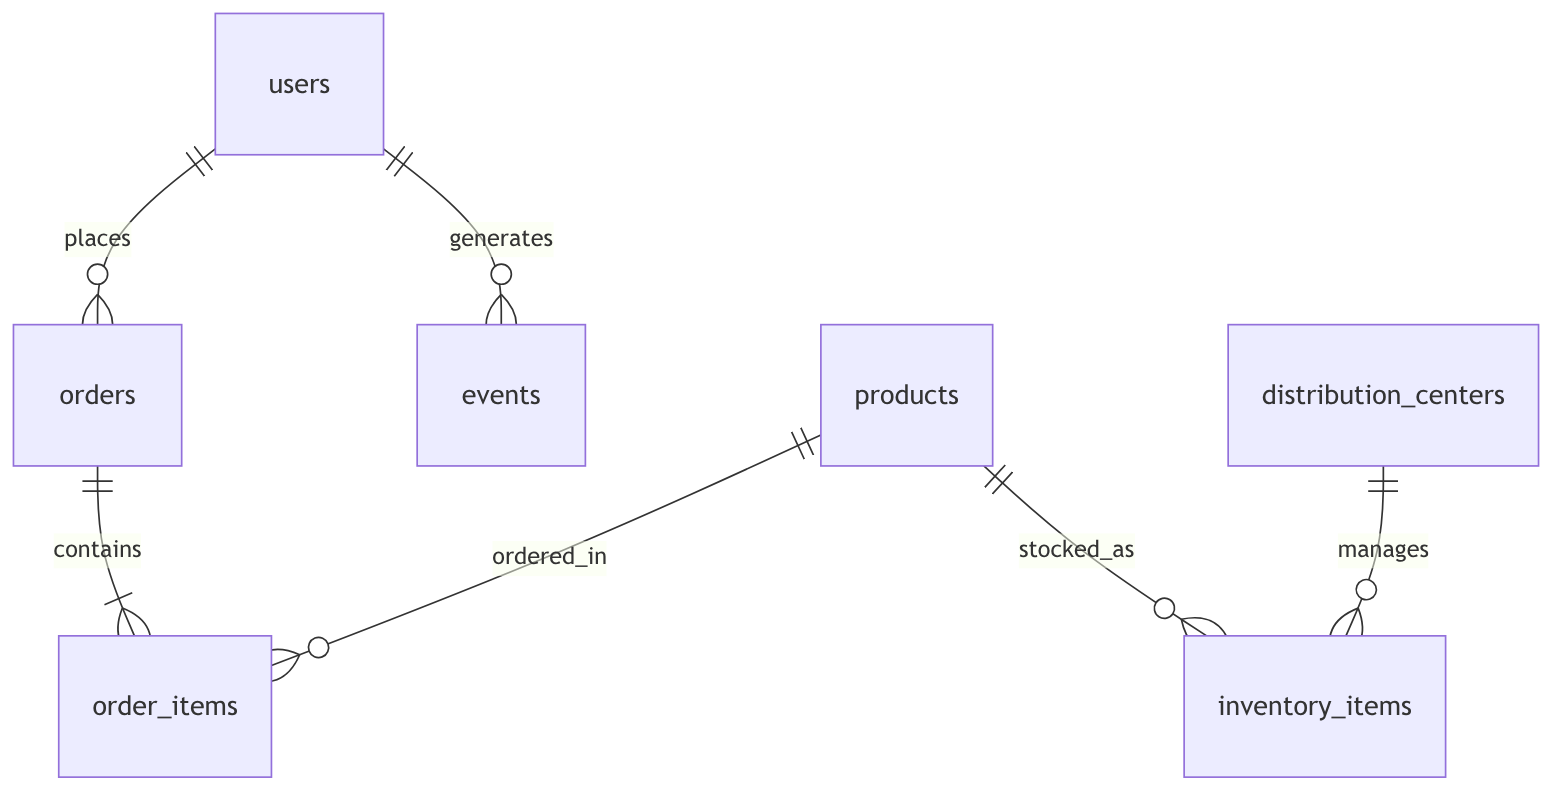

---

## 3. Learning Objectives & Pipeline Stages

### Learning Objectives
1. **Data Profiling**: Extract and interpret column distribution metrics, null percentages, uniqueness ratios, and descriptive statistics.
2. **Data Quality**: Automatically generate schema-driven quality rules to enforce non-null constraints, primary key uniqueness, and valid geographic ranges.
3. **Batch Pipeline Orchestration**: Trigger asynchronous DataScan jobs across all 7 tables in parallel and monitor their lifecycle to completion.

### Pipeline Stages
1. **Environment Setup**: Initialize BigQuery client, AuthorizedSession OAuth2 transport, and dynamic region detection
2. **Common Utilities**: Implement Knowledge Catalog REST request helper and asynchronous job polling/labeling functions
3. **Scan Creation Helpers**: Define automated profile and quality scan configuration logic
4. **Batch Execution & Monitoring**: Concurrently trigger scans across all 7 tables with self-healing table readiness validation
5. **Results Inspection**: Query persistent BigQuery result tables and verify results in the BigQuery Studio UI


## Step 1: Environment & REST API Setup

Load Google Cloud credentials and initialize the BigQuery client and REST API session. The target dataset location (`LOCATION`) is dynamically detected from BigQuery metadata to ensure compatibility with your deployment region.

> [!TIP]
> **Troubleshooting Authentication (`401 Unauthorized`) Errors**
>
> If you encounter a `401 Unauthorized: Request had invalid authentication credentials` error during API calls, run the following command in the Cloud Shell terminal to perform manual re-authentication:
> ```bash
> gcloud auth application-default login --no-launch-browser --quiet
> ```
> Follow the URL to retrieve your verification code, enter it in Cloud Shell, and select **Runtime** > **Restart session** in the top menu before re-running the cells.


In [ ]:
# [Qwiklabs Environment] If you encounter an HTTP Error 401 (Invalid authentication credentials) error during Dataplex API calls,
# uncomment and run the line below to perform manual authentication:
# !gcloud auth application-default login --no-launch-browser --quiet

import datetime
import json
import re
import ssl
import subprocess
import time
import urllib.error
import urllib.request

import google.auth
from google.auth.transport.requests import AuthorizedSession, Request
from google.cloud import bigquery

# 1. Dynamically retrieve the Google Cloud project ID
_, PROJECT_ID = google.auth.default()

DATASET_ID = "thelook_ecommerce"

# 2. Configure BigQuery client in auto-refresh mode
bq_client = bigquery.Client(project=PROJECT_ID)

# Dynamically resolve dataset location to match deployment region
try:
    LOCATION = bq_client.get_dataset(DATASET_ID).location
except Exception:
    LOCATION = "us-central1"

# 3. Initialize AuthorizedSession for official REST API calls
credentials, _ = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
authed_session = AuthorizedSession(credentials)

print(
    f"Detected Project ID: {PROJECT_ID}, Target Dataset: {DATASET_ID}, Region: {LOCATION}"
)
print(
    "Google Cloud environment and API authentication configured successfully!"
)

## Step 2: Define Common API Helper Functions

In [ ]:
# [Common Utility] Knowledge Catalog REST API request helper


def make_rest_request(url, method="GET", body_dict=None, max_retries=5):
    """Executes REST API requests using AuthorizedSession with automatic OAuth2 token management and required headers."""
    retries = 0
    backoff = 2  # Initial backoff in seconds

    while True:
        try:
            if method == "GET":
                response = authed_session.get(url, timeout=60)
            elif method == "POST":
                response = authed_session.post(url, json=body_dict, timeout=60)
            elif method == "DELETE":
                response = authed_session.delete(url, timeout=60)
            else:
                response = authed_session.request(
                    method, url, json=body_dict, timeout=60
                )

            if response.status_code >= 400:
                # Exponential backoff retry on HTTP 429 Quota/Rate Limit
                if response.status_code == 429 and retries < max_retries:
                    print(
                        f"  [429 Quota Exceeded] Retrying in {backoff}s (Attempt {retries + 1}/{max_retries})..."
                    )
                    time.sleep(backoff)
                    retries += 1
                    backoff *= 2
                    continue
                raise Exception(
                    f"HTTP Error {response.status_code} - {response.text}"
                )

            return response.json()

        except Exception as e:
            if "HTTP Error" in str(e):
                raise e
            if retries < max_retries:
                time.sleep(backoff)
                retries += 1
                backoff *= 2
                continue
            raise e


# [Common Utility] Run DataScan job and poll until completion


def run_datascan_and_wait(scan_id):
    """Runs a DataScan job and polls status every 10 seconds until completion (SUCCEEDED), returning full scan details."""
    run_url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/dataScans/{scan_id}:run"
    print(f"  -> Requesting DataScan execution (Scan ID: {scan_id})...")
    run_res = make_rest_request(run_url, method="POST")

    job_name = run_res["job"]["name"]
    job_id = run_res["job"]["uid"]
    print(
        f"  -> Execution Job ID: {job_id} (Starting status polling until completion...)"
    )

    job_url = f"https://dataplex.googleapis.com/v1/{job_name}?view=FULL"
    while True:
        job = make_rest_request(job_url, method="GET")
        state = job.get("state")
        print(f"     [Polling] Current job state: {state}")

        if state == "SUCCEEDED":
            print("  -> Scan completed successfully!")
            return job
        elif state in ["FAILED", "CANCELLED"]:
            raise Exception(f"DataScan Job execution error (State: {state})")

        time.sleep(10)


# [Common Utility] Trigger asynchronous DataScan job (non-blocking)


def trigger_datascan(scan_id):
    """Triggers a DataScan execution job and immediately returns the job name without blocking."""
    run_url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/dataScans/{scan_id}:run"
    run_res = make_rest_request(run_url, method="POST")
    return run_res["job"]["name"]


# [Common Utility] Monitor asynchronous DataScan jobs and publish table labels upon completion


def monitor_datascan_jobs_and_label(active_jobs, poll_interval_seconds=30):
    """Monitors running DataScan jobs in real-time. Upon successful completion (SUCCEEDED),

    automatically attaches official publishing labels to the target BigQuery table.
    """
    total_triggered = len(active_jobs)
    print(
        f"\nTriggered {total_triggered} DataScan jobs concurrently. Starting progress monitoring."
    )
    print(
        f"({poll_interval_seconds}s polling interval; labels will be attached to tables upon completion.)\n"
    )

    while active_jobs:
        status_summary = {
            "PENDING": 0,
            "RUNNING": 0,
            "SUCCEEDED": 0,
            "FAILED": 0,
            "CANCELLED": 0,
        }

        for job_name in list(active_jobs.keys()):
            job_url = f"https://dataplex.googleapis.com/v1/{job_name}"
            try:
                job = make_rest_request(job_url, method="GET")
                state = job.get("state", "UNKNOWN")

                status_summary[state] = status_summary.get(state, 0) + 1

                if state in ["SUCCEEDED", "FAILED", "CANCELLED"]:
                    t_id, s_type = active_jobs[job_name]
                    print(
                        f"  [Done] '{t_id}' {s_type} job finished (Status: {state})"
                    )

                    if state == "SUCCEEDED":
                        try:
                            table_ref = bq_client.dataset(DATASET_ID).table(
                                t_id
                            )
                            table = bq_client.get_table(table_ref)

                            labels = dict(table.labels or {})
                            scan_id = (
                                f"dp-thelook-{t_id}".lower().replace("_", "-")
                                if s_type == "Profile"
                                else f"dq-thelook-{t_id}".lower().replace(
                                    "_", "-"
                                )
                            )

                            # Official Google Cloud Console label prefixes (dataplex-dp-* and dataplex-dq-*)
                            prefix = (
                                "dataplex-dp"
                                if s_type == "Profile"
                                else "dataplex-dq"
                            )
                            labels[f"{prefix}-published-scan"] = scan_id
                            labels[f"{prefix}-published-project"] = PROJECT_ID
                            labels[f"{prefix}-published-location"] = LOCATION

                            # Long-form labels for backward compatibility
                            labels[
                                f"dataplex-data-{s_type.lower()}-published-scan"
                            ] = scan_id
                            labels[
                                f"dataplex-data-{s_type.lower()}-published-project"
                            ] = PROJECT_ID
                            labels[
                                f"dataplex-data-{s_type.lower()}-published-location"
                            ] = LOCATION

                            table.labels = labels
                            bq_client.update_table(table, ["labels"])
                            print(
                                f"    -> Successfully attached {s_type} publishing label to table '{t_id}'!"
                            )
                        except Exception as le:
                            print(f"    -> Error labeling table '{t_id}': {le}")

                    del active_jobs[job_name]
            except Exception as e:
                pass

        if active_jobs:
            running_cnt = status_summary.get("RUNNING", 0) + status_summary.get(
                "PENDING", 0
            )
            succeeded_cnt = (
                total_triggered
                - len(active_jobs)
                - status_summary.get("FAILED", 0)
                - status_summary.get("CANCELLED", 0)
            )

            print(
                f"[Status] Running: {running_cnt} | Succeeded: {succeeded_cnt} | Failed: {status_summary.get('FAILED', 0)}",
                end="\r",
            )
            time.sleep(poll_interval_seconds)

    print(
        "\n\n=== [All Table DataScan Monitoring and Label Mapping Completed] ==="
    )

## Step 3: Create Data Profile and Quality Scans

In [ ]:
# [Data Profile] Retrieve or create Data Profile Scan


def get_or_create_data_profile_scan(table_id, sampling_percent=100.0):
    """
    Retrieves the DATA_PROFILE DataScan for the target table, or creates a new one if not found.
    Exports profile results to the 'datascan_profile_results' table in BigQuery.
    """
    scan_id = f"dp-thelook-{table_id}".lower().replace("_", "-")
    get_url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/dataScans/{scan_id}"

    try:
        scan = make_rest_request(get_url, method="GET")
        print(f"  -> Found existing Data Profile Scan: {scan_id}")
        return scan_id
    except Exception as e:
        if "404" in str(e) or "does not exist" in str(e):
            print(f"  -> Creating new Data Profile Scan: {scan_id}...")
            create_url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/dataScans?dataScanId={scan_id}"
            export_table = f"//bigquery.googleapis.com/projects/{PROJECT_ID}/datasets/{DATASET_ID}/tables/datascan_profile_results"

            body = {
                "data": {
                    "resource": f"//bigquery.googleapis.com/projects/{PROJECT_ID}/datasets/{DATASET_ID}/tables/{table_id}"
                },
                "executionSpec": {"trigger": {"onDemand": {}}},
                "type": "DATA_PROFILE",
                "dataProfileSpec": {
                    "samplingPercent": sampling_percent,
                    "postScanActions": {
                        "bigqueryExport": {"resultsTable": export_table}
                    },
                    "catalogPublishingEnabled": True,
                },
            }
            operation = make_rest_request(
                create_url, method="POST", body_dict=body
            )
            op_name = operation["name"]

            while True:
                op_status = make_rest_request(
                    f"https://dataplex.googleapis.com/v1/{op_name}",
                    method="GET",
                )
                if op_status.get("done"):
                    if "error" in op_status:
                        raise Exception(
                            f"Data Profile Scan creation failed: {op_status['error']}"
                        )
                    break
                time.sleep(5)
            print(f"  -> Data Profile Scan created successfully: {scan_id}")
            return scan_id
        else:
            raise e

In [ ]:
# [Data Quality] Dynamic Quality Rule Generator based on BigQuery Schema


def generate_default_quality_rules(table_id):
    """
    Dynamically inspects BigQuery schema to generate logical default data quality rules,
    adapting flexibly to table specification changes without hardcoded rules.
    """
    table_ref = bq_client.dataset(DATASET_ID).table(table_id)
    table = bq_client.get_table(table_ref)

    VALID_RANGES = {
        "latitude": {
            "min": "-90",
            "max": "90",
            "desc": "Latitude coordinates must be within valid range (-90 to 90).",
        },
        "longitude": {
            "min": "-180",
            "max": "180",
            "desc": "Longitude coordinates must be within valid range (-180 to 180).",
        },
    }

    rules = []

    for field in table.schema:
        field_type = field.field_type.upper()

        # 1. COMPLETENESS Dimension: REQUIRED columns must not contain NULL values
        if field.mode == "REQUIRED":
            rules.append(
                {
                    "column": field.name,
                    "dimension": "COMPLETENESS",
                    "nonNullExpectation": {},
                    "description": f"Column {field.name} is REQUIRED and must not contain NULL values.",
                }
            )

        # 2. UNIQUENESS Dimension: Primary key 'id' column must contain unique values
        if field.name == "id":
            rules.append(
                {
                    "column": field.name,
                    "dimension": "UNIQUENESS",
                    "uniquenessExpectation": {},
                    "description": f"Column {field.name} is a unique record identifier and must not contain duplicates.",
                }
            )

        # 3. VALIDITY Dimension: Coordinate ranges validation
        if field.name in VALID_RANGES and field_type in ("FLOAT", "INTEGER"):
            range_spec = VALID_RANGES[field.name]
            rules.append(
                {
                    "column": field.name,
                    "dimension": "VALIDITY",
                    "rangeExpectation": {
                        "minValue": range_spec["min"],
                        "maxValue": range_spec["max"],
                    },
                    "description": range_spec["desc"],
                }
            )

    return rules


# [Data Quality] Retrieve or create Data Quality Scan


def get_or_create_data_quality_scan(table_id, sampling_percent=100.0):
    """
    Retrieves the DATA_QUALITY DataScan for the target table, or creates a new one if not found.
    Exports quality verification results to 'datascan_quality_results' in BigQuery.
    """
    scan_id = f"dq-thelook-{table_id}".lower().replace("_", "-")
    get_url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/dataScans/{scan_id}"

    try:
        scan = make_rest_request(get_url, method="GET")
        print(f"  -> Found existing Data Quality Scan: {scan_id}")
        return scan_id
    except Exception as e:
        if "404" in str(e) or "does not exist" in str(e):
            print(f"  -> Creating new Data Quality Scan: {scan_id}...")
            create_url = f"https://dataplex.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/dataScans?dataScanId={scan_id}"

            rules = generate_default_quality_rules(table_id)
            if not rules:
                fields_list = [
                    f.name
                    for f in bq_client.get_table(
                        bq_client.dataset(DATASET_ID).table(table_id)
                    ).schema
                ]
                check_col = (
                    "id"
                    if "id" in fields_list
                    else bq_client.get_table(
                        bq_client.dataset(DATASET_ID).table(table_id)
                    )
                    .schema[0]
                    .name
                )
                rules = [
                    {
                        "column": check_col,
                        "dimension": "COMPLETENESS",
                        "nonNullExpectation": {},
                        "description": "Default non-null check",
                    }
                ]

            export_table = f"//bigquery.googleapis.com/projects/{PROJECT_ID}/datasets/{DATASET_ID}/tables/datascan_quality_results"

            body = {
                "data": {
                    "resource": f"//bigquery.googleapis.com/projects/{PROJECT_ID}/datasets/{DATASET_ID}/tables/{table_id}"
                },
                "executionSpec": {"trigger": {"onDemand": {}}},
                "type": "DATA_QUALITY",
                "dataQualitySpec": {
                    "rules": rules,
                    "samplingPercent": sampling_percent,
                    "postScanActions": {
                        "bigqueryExport": {"resultsTable": export_table}
                    },
                    "catalogPublishingEnabled": True,
                },
            }
            operation = make_rest_request(
                create_url, method="POST", body_dict=body
            )
            op_name = operation["name"]

            while True:
                op_status = make_rest_request(
                    f"https://dataplex.googleapis.com/v1/{op_name}",
                    method="GET",
                )
                if op_status.get("done"):
                    if "error" in op_status:
                        raise Exception(
                            f"Data Quality Scan creation failed: {op_status['error']}"
                        )
                    break
                time.sleep(5)
            print(f"  -> Data Quality Scan created successfully: {scan_id}")
            return scan_id
        else:
            raise e

## Step 4: Batch Execution and Monitoring Pipeline

Trigger Data Profile and Data Quality scans across all target tables (`users`, `orders`, `order_items`, `products`, `events`, `inventory_items`, `distribution_centers`) in parallel.

> [!NOTE]
> **Self-Healing Table Replication Check**
>
> This step automatically verifies that all 7 required tables exist in `thelook_ecommerce`. If BigQuery Data Transfer replication is still in progress, it triggers a manual transfer run if necessary and polls until all tables are populated before starting the DataScans.

### Monitoring Progress in the Google Cloud Console
While scans are running, navigate to **Dataplex** > **Metadata curation** > **Data profiling & quality** in the Google Cloud Console to view live job statuses:
- `dp-thelook-<table_name>`: Type `Data profile`, Status `Running` / `Succeeded`
- `dq-thelook-<table_name>`: Type `Data quality`, Status `Running` / `Succeeded`


In [ ]:
# [Main Pipeline] Batch metadata profiling and quality scans across all tables
# Triggers all table scans asynchronously in parallel and monitors their status.


ALL_TABLES = [
    "users",
    "orders",
    "order_items",
    "products",
    "events",
    "inventory_items",
    "distribution_centers",
]


def ensure_dataset_ready(dataset_id, expected_tables, max_wait_seconds=300):
    """
    Verifies that target tables exist in the BigQuery dataset.
    If replication from bigquery-public-data is still in progress,
    initiates a manual transfer run and polls until all tables appear.
    """
    start_time = time.time()
    print(f"Verifying table readiness in dataset '{dataset_id}'...")

    while time.time() - start_time < max_wait_seconds:
        existing = {t.table_id for t in bq_client.list_tables(dataset_id)}
        missing = [t for t in expected_tables if t not in existing]

        if not missing:
            print(
                f"All {len(expected_tables)} required tables are present in '{dataset_id}'."
            )
            return True

        print(
            f"Replication in progress: {len(existing)}/{len(expected_tables)} tables present. Missing: {missing}"
        )

        # Check if DTS transfer config exists and trigger manual run if needed
        try:
            list_url = f"https://bigquerydatatransfer.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/transferConfigs"
            configs_res = make_rest_request(list_url, method="GET")
            for cfg in configs_res.get("transferConfigs", []):
                if cfg.get("destinationDatasetId") == dataset_id:
                    cfg_name = cfg["name"]
                    runs_url = f"https://bigquerydatatransfer.googleapis.com/v1/{cfg_name}/runs"
                    runs_res = make_rest_request(runs_url, method="GET")
                    runs = runs_res.get("transferRuns", [])
                    has_active = any(
                        r.get("state") in ["PENDING", "RUNNING"]
                        for r in runs[:3]
                    )
                    if not has_active:
                        print(
                            f"  -> Triggering manual transfer run for config '{cfg.get('displayName')}'..."
                        )
                        now_str = datetime.datetime.now(
                            datetime.timezone.utc
                        ).strftime("%Y-%m-%dT%H:%M:%SZ")
                        trigger_url = f"https://bigquerydatatransfer.googleapis.com/v1/{cfg_name}:startManualRuns"
                        make_rest_request(
                            trigger_url,
                            method="POST",
                            body_dict={"requestedRunTime": now_str},
                        )
                        print("  -> Transfer run initiated successfully.")
                    break
        except Exception:
            try:
                cmd = f'bq mk --transfer_run --run_time="$(date -u +%Y-%m-%dT%H:%M:%SZ)" $(bq ls --transfer_config --transfer_location={LOCATION} --format="value(name)" | head -n 1)'
                subprocess.run(cmd, shell=True, capture_output=True)
            except Exception:
                pass

        print("Waiting 15 seconds for tables to replicate...")
        time.sleep(15)

    print(
        f"Warning: Timed out waiting for tables after {max_wait_seconds}s. Proceeding with available tables."
    )
    return False


ensure_dataset_ready(DATASET_ID, ALL_TABLES)

print("\n=== [Automated Batch Execution of Data Profile and Quality Scans] ===")

active_jobs = {}  # {job_name: (table_id, scan_type)}

for t_id in ALL_TABLES:
    print(f"  -> Triggering scans for table '{t_id}'...")
    try:
        # A. Profile scan with 10% sampling
        dp_scan = get_or_create_data_profile_scan(t_id, sampling_percent=10.0)
        dp_job_name = trigger_datascan(dp_scan)
        active_jobs[dp_job_name] = (t_id, "Profile")

        # B. Quality scan with 10% sampling
        dq_scan = get_or_create_data_quality_scan(t_id, sampling_percent=10.0)
        dq_job_name = trigger_datascan(dq_scan)
        active_jobs[dq_job_name] = (t_id, "Quality")

        time.sleep(3)

    except Exception as e:
        print(f"  [Error] Failed to trigger table '{t_id}': {e}")

# Start asynchronous monitoring process
monitor_datascan_jobs_and_label(active_jobs, poll_interval_seconds=30)

## Step 5: Query and Verify Results

Once scan execution completes, summary metadata is automatically exported to BigQuery and published directly to the BigQuery Studio table details UI.

### 1. Inspecting Results in BigQuery Studio UI
In the BigQuery Studio Explorer panel, navigate to `thelook_ecommerce` > `users` and inspect:
- **Data Profile Tab**: View null percentages, unique percentages, mean/standard deviation, and Top 10 value distribution charts for each column (`age`, `city`, `country`, etc.).
- **Data Quality Tab**:
  - **Overall Score**: `100%` (green checkmark)
  - **Rule Summary**: `3 passed rules` (primary key uniqueness, latitude coordinate range, longitude coordinate range)
  - **Dimension Scores**: Uniqueness `100%`, Validity `100%`

> [!NOTE]
>
> BigQuery Studio UI metadata synchronization may take several minutes to
> populate the **Data Profile** and **Data Quality** tabs in table details.
> The BigQuery tables `datascan_profile_results` and `datascan_quality_results`
> queried below are populated immediately upon job completion and serve as
> the authoritative, instant source of truth.

### 2. Persistent BigQuery Governance Tables
All scan results are permanently stored in the `datascan_profile_results` and `datascan_quality_results` tables in BigQuery, serving as the foundational audit source for ongoing data governance and quality monitoring dashboards.

In [ ]:
# Target table for inspecting results
TEST_TABLE = "users"

### Inspect Data Profile Results

Detailed Data Profile scan results are exported to the designated BigQuery table (`datascan_profile_results`). Run the query below to view the latest profiling results.

In [ ]:
# [BigQuery Query] Retrieve latest data profile results
query = f"""
SELECT 
    column_name,
    column_type,
    percent_null,
    percent_unique,
    min_value,
    max_value,
    average_value
FROM `{PROJECT_ID}.{DATASET_ID}.datascan_profile_results`
WHERE data_source.table_id = '{TEST_TABLE}'
  AND job_start_time = (
      SELECT MAX(job_start_time) 
      FROM `{PROJECT_ID}.{DATASET_ID}.datascan_profile_results`
      WHERE data_source.table_id = '{TEST_TABLE}'
  )
ORDER BY column_name
"""
print(f"Executing query to retrieve profile results for '{TEST_TABLE}'...")
df = bq_client.query(query).to_dataframe()
df

### Inspect Data Quality Results

Data Quality verification results are exported to the designated BigQuery table (`datascan_quality_results`). Run the query below to inspect pass/fail metrics and rule evaluation details.

In [ ]:
# [BigQuery Query] Retrieve latest data quality results
query = f"""
SELECT 
    rule_column,
    rule_dimension,
    rule_description,
    rule_passed,
    rule_rows_evaluated,
    rule_rows_passed,
    rule_rows_passed_percent
FROM `{PROJECT_ID}.{DATASET_ID}.datascan_quality_results`
WHERE data_source.table_id = '{TEST_TABLE}'
  AND job_start_time = (
      SELECT MAX(job_start_time) 
      FROM `{PROJECT_ID}.{DATASET_ID}.datascan_quality_results`
      WHERE data_source.table_id = '{TEST_TABLE}'
  )
ORDER BY rule_column
"""
print(f"Executing query to retrieve quality results for '{TEST_TABLE}'...")
df = bq_client.query(query).to_dataframe()
df